# Urbanization Analysis with Satellite Imagery in Allen, TX


### 🔹 What is `geemap`?

`geemap` is a **Python package** that provides an easy interface to work with **Google Earth Engine (GEE)** in **Jupyter or Colab notebooks**.

---

### 🔧 What does it do?

* Lets you **access and visualize satellite data** from GEE
* Supports **interactive maps** using Leaflet or ipyleaflet
* Makes it easier to:

  * Search, filter, and plot satellite imagery
  * Export data from Earth Engine
  * Do time-series and land cover analysis

---

### ✅ Why use it?

* It’s **designed for students, researchers, and data scientists**
* Simplifies tasks that would require complex GEE JavaScript code
* Perfect for **environmental, urban, and geospatial analysis**


### Introduction of Earth Engine
Earth Engine is a powerful tool for planetary scale geospatial analysis, and has been used for climate, sustainability, and environmental science and impact work for over a decade. Analyze and visualize geospatial datasets. Draw from 80+ petabytes of data from the Earth Engine Data Catalog, or use your own.

To run the one, need to have Earth Engine enabled

https://console.cloud.google.com/earth-engine/welcome?inv=1&invt=Ab07tg


To enable Earth Engine, **one must register the project**.
I registered mine as non-commercial after filling out a series of questions.
My project was created under the default name "My First Project", which is quite silly. However, **it comes with the project ID**.

Step 1: Visit This Link
Go to 👉 https://code.earthengine.google.com/
Log in and accept any updated terms if you haven’t already.

Step 2: Enable Earth Engine in Google Cloud
Go to 👉 Google Cloud Console:

Create a new project or select an existing one.

Enable the Earth Engine API for that project.

Search for Earth Engine API in the top bar > Click Enable



In [5]:
# need the newer version to work with upgraded Earth Engine
!pip install earthengine-api --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.0/463.0 kB 7.1 MB/s eta 0:00:00


In [2]:
# import geemap
# import ee
import datetime
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import ee
print(ee.__version__)
ee.Authenticate()  # Regular auth — follow the link and paste the token
ee.Initialize(project='utility-realm-255220')

1.5.21


In [4]:
import geemap
geemap.ee_initialize()

In [7]:
# 3. Define region of interest (Allen, TX)
# Format: [west_lon, south_lat, east_lon, north_lat]
# roi = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])  # Approximate bounding box for Allen
# 33.0700, -96.6240 | 33.1400, -96.7140

roi = ee.Geometry.Rectangle([-97.5, 32.3, -96.3, 33.3]) # Approximate boudning box for DFW metrox


| Class              | % in 2020 | % in 2021 | Change     |
| ------------------ | --------- | --------- | ---------- |
| 🌳 Tree Cover      | 20.7%     | 18.14%    | **−2.56%** |
| 🌾 Grassland       | 15.78%    | 17.66%    | **+1.88%** |
| 🌱 Cropland        | 3.04%     | 3.13%     | ≈ (same)   |
| 🏘 Built-up        | 53.15%    | 58.44%    | **+5.29%** |
| 🏜 Bare Vegetation | 7.04%     | 2.38%     | **−4.66%** |

Allen experienced notable urban expansion, with built-up areas increasing over 5 percentage points in just one year.

Likely explanation: conversion of bare or sparsely vegetated land and tree cover into housing or commercial developments.

The European Space Agency https://worldcover2021.esa.int/

fast generation and validation of a world land cover based on Sentinel-2 and Sentinel-1 constellations

- 10 land cover classes + mangroves
- 10m resolution
- 10 months from last data take
- 77% overall accuracy, independently validated



Here's the ESA Cover viewer
https://viewer.esa-worldcover.org/worldcover/?language=en&bbox=-96.78418412178772,33.077829203177316,-96.66253192907753,33.12782920317731&overlay=false&bgLayer=OSM&date=2025-06-24&layer=WORLDCOVER_2021_MAP

## Calculate Land Use Change using Bounding Box Approach

In [23]:
# Define a reusable function to compute ESA WorldCover statistics for a given ROI

def analyze_worldcover_change(roi, title='Land Cover Composition'):
    # 1. Load ESA WorldCover land cover classification
    worldcover_datasets = {
        2020: ee.Image("ESA/WorldCover/v100/2020"),
        2021: ee.Image("ESA/WorldCover/v200/2021")
    }

    # 2. Define legend classes of interest
    class_labels = {
        10: 'Tree cover',
        20: 'Shrubland',
        30: 'Grassland',
        40: 'Cropland',
        50: 'Built-up',
        60: 'Bare / sparse vegetation',
        70: 'Snow and ice',
        80: 'Permanent water bodies',
        90: 'Herbaceous wetland',
        95: 'Mangroves',
        100: 'Moss and lichen'
    }

    # 3. Clip and prepare images
    images = {}
    for year, dataset in worldcover_datasets.items():
        images[year] = dataset.select('Map').clip(roi)

    # 4. Compute class percentages
    def get_class_percentages(image):
        stats = image.reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(),
            geometry=roi,
            scale=10,
            maxPixels=1e9
        )
        freq_dict = stats.get('Map').getInfo()
        total = sum(freq_dict.values())
        result = {}
        for class_id, label in class_labels.items():
            count = freq_dict.get(str(class_id), 0)
            result[label] = round(100 * count / total, 2)
        return result

    # 5. Collect stats for each year
    cover_stats = {}
    for year, img in images.items():
        cover_stats[year] = get_class_percentages(img)
        print(f"\nLand cover for {year}:")
        for k, v in cover_stats[year].items():
            print(f"  {k}: {v}%")

    # 6. Plot chart
    import numpy as np
    import matplotlib.pyplot as plt

    labels = list(class_labels.values())
    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))
    vals_2020 = [cover_stats[2020].get(lbl, 0) for lbl in labels]
    vals_2021 = [cover_stats[2021].get(lbl, 0) for lbl in labels]

    rects1 = ax.bar(x - width/2, vals_2020, width, label='2020')
    rects2 = ax.bar(x + width/2, vals_2021, width, label='2021')

    ax.set_ylabel('% Land Cover')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()


Land cover for 2020:
  Tree cover: 20.7%
  Shrubland: 0.0%
  Grassland: 15.78%
  Cropland: 3.04%
  Built-up: 53.15%
  Bare / sparse vegetation: 7.04%
  Snow and ice: 0.0%
  Permanent water bodies: 0.29%
  Herbaceous wetland: 0.0%
  Mangroves: 0.0%
  Moss and lichen: 0.0%

Land cover for 2021:
  Tree cover: 18.14%
  Shrubland: 0.0%
  Grassland: 17.66%
  Cropland: 3.13%
  Built-up: 58.44%
  Bare / sparse vegetation: 2.38%
  Snow and ice: 0.0%
  Permanent water bodies: 0.25%
  Herbaceous wetland: 0.0%
  Mangroves: 0.0%
  Moss and lichen: 0.0%


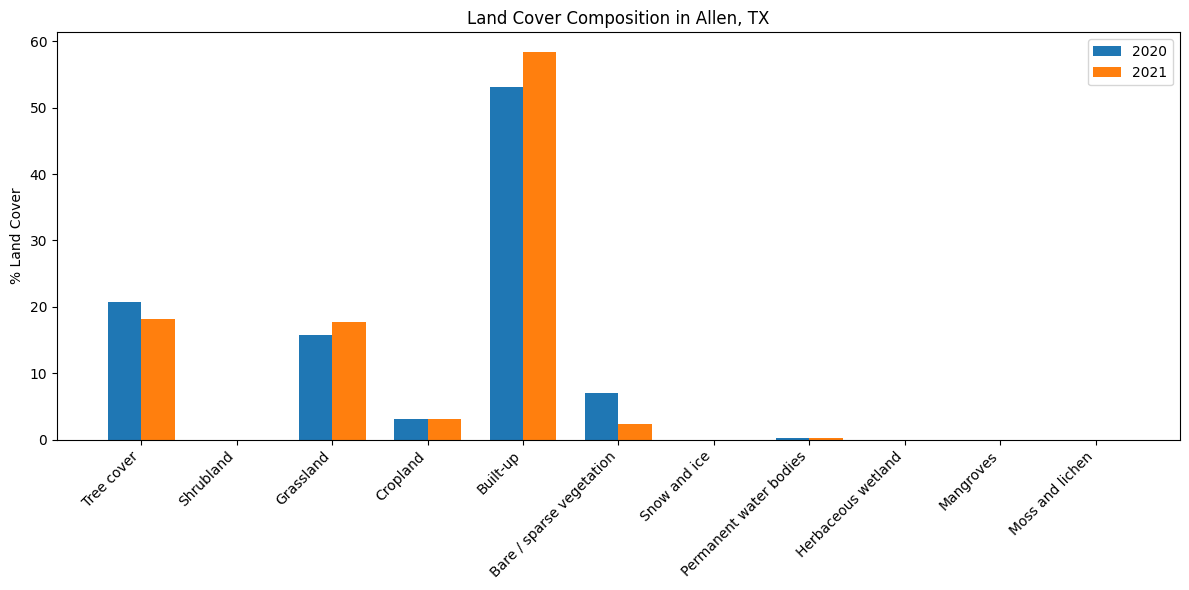

In [24]:
 # calculate land use change for Allen (bounding box approach)
roi = ee.Geometry.Rectangle([-96.7140, 33.0700, -96.6240, 33.1400])
analyze_worldcover_change(roi, title='Land Cover Composition in Allen, TX')


Land cover for 2020:
  Tree cover: 24.87%
  Shrubland: 0.0%
  Grassland: 38.12%
  Cropland: 8.56%
  Built-up: 18.52%
  Bare / sparse vegetation: 5.86%
  Snow and ice: 0.0%
  Permanent water bodies: 4.03%
  Herbaceous wetland: 0.04%
  Mangroves: 0.0%
  Moss and lichen: 0.0%

Land cover for 2021:
  Tree cover: 25.59%
  Shrubland: 0.0%
  Grassland: 38.59%
  Cropland: 8.57%
  Built-up: 21.1%
  Bare / sparse vegetation: 1.99%
  Snow and ice: 0.0%
  Permanent water bodies: 4.12%
  Herbaceous wetland: 0.04%
  Mangroves: 0.0%
  Moss and lichen: 0.0%


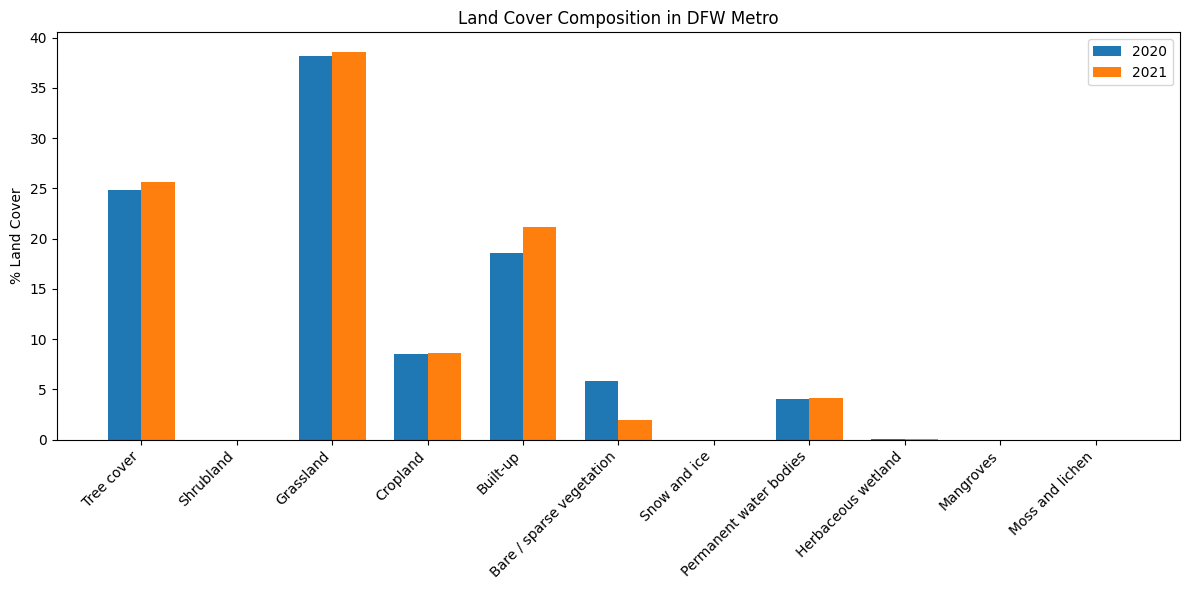

In [7]:
 # calculate land use change for DFW Metrox (bounding box approach)
roi = ee.Geometry.Rectangle([-97.5, 32.3, -96.3, 33.3])
analyze_worldcover_change(roi, title='Land Cover Composition in DFW Metro')

## Calculate DFW Metro Land Use Change Aggregated View


Land cover for 2020:
  Tree cover: 27.35%
  Shrubland: 0.0%
  Grassland: 46.19%
  Cropland: 7.66%
  Built-up: 10.74%
  Bare / sparse vegetation: 4.44%
  Snow and ice: 0.0%
  Permanent water bodies: 3.59%
  Herbaceous wetland: 0.02%
  Mangroves: 0.0%
  Moss and lichen: 0.0%

Land cover for 2021:
  Tree cover: 28.77%
  Shrubland: 0.0%
  Grassland: 46.38%
  Cropland: 7.78%
  Built-up: 12.04%
  Bare / sparse vegetation: 1.36%
  Snow and ice: 0.0%
  Permanent water bodies: 3.65%
  Herbaceous wetland: 0.02%
  Mangroves: 0.0%
  Moss and lichen: 0.0%


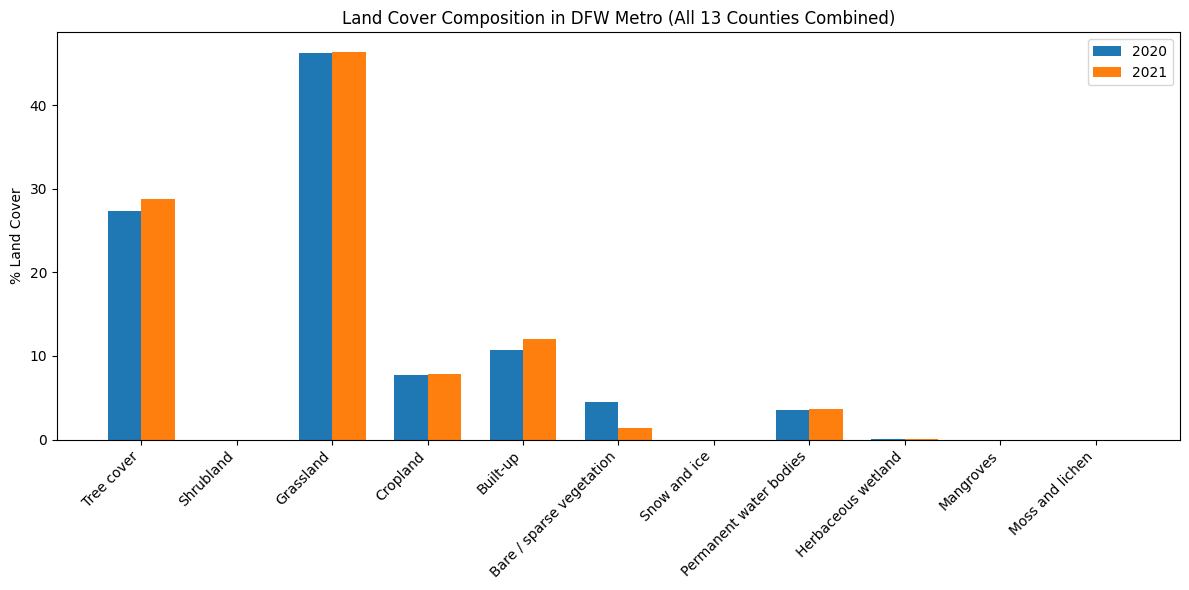

In [38]:
dfw_counties = ['Collin', 'Dallas', 'Denton', 'Ellis', 'Hood', 'Hunt', 'Johnson', 'Kaufman', 'Parker', 'Rockwall', 'Somervell', 'Tarrant', 'Wise']
counties = ee.FeatureCollection("TIGER/2018/Counties")

dfw_metro = counties.filter(
    ee.Filter.And(
        ee.Filter.inList('NAME', dfw_counties),
        ee.Filter.eq('STATEFP', '48')  # Texas
    )
).geometry()

analyze_worldcover_change(dfw_metro, title="Land Cover Composition in DFW Metro (All 13 Counties Combined)")


Land cover for 2020:
  Tree cover: 26.24%
  Shrubland: 0.0%
  Grassland: 33.32%
  Cropland: 6.61%
  Built-up: 22.32%
  Bare / sparse vegetation: 6.37%
  Snow and ice: 0.0%
  Permanent water bodies: 5.12%
  Herbaceous wetland: 0.02%
  Mangroves: 0.0%
  Moss and lichen: 0.0%

Land cover for 2021:
  Tree cover: 26.33%
  Shrubland: 0.0%
  Grassland: 33.91%
  Cropland: 7.04%
  Built-up: 25.33%
  Bare / sparse vegetation: 2.18%
  Snow and ice: 0.0%
  Permanent water bodies: 5.2%
  Herbaceous wetland: 0.02%
  Mangroves: 0.0%
  Moss and lichen: 0.0%


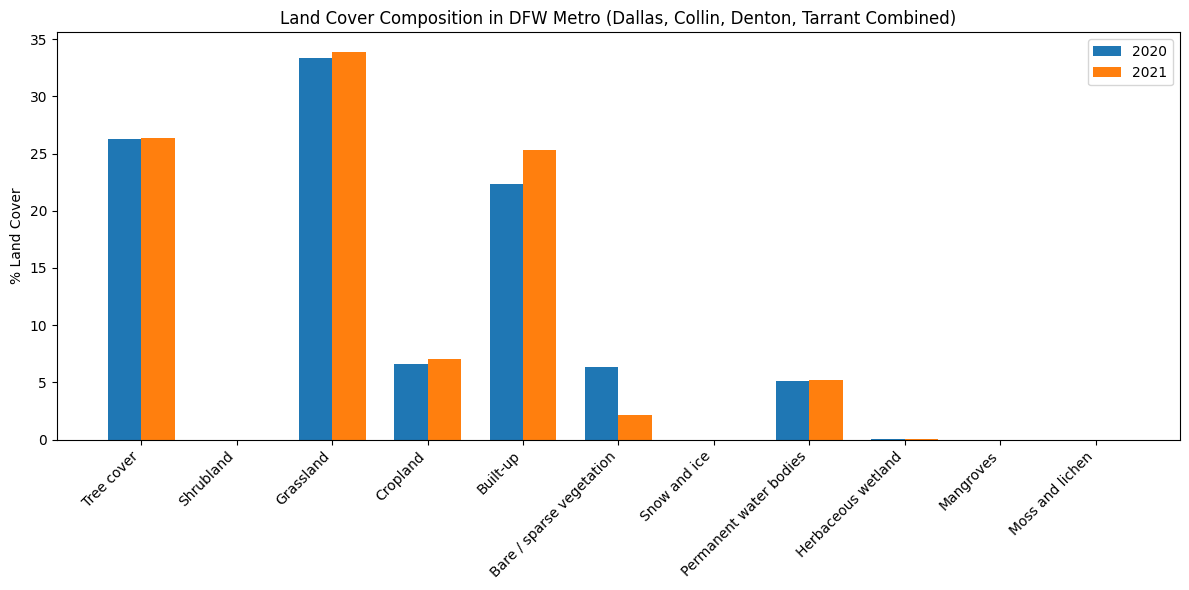

In [37]:
most_populated_dfw_counties = ['Collin', 'Dallas', 'Denton', 'Tarrant']
counties = ee.FeatureCollection("TIGER/2018/Counties")

dfw_metro = counties.filter(
    ee.Filter.And(
        ee.Filter.inList('NAME', most_populated_dfw_counties),
        ee.Filter.eq('STATEFP', '48')  # Texas
    )
).geometry()

analyze_worldcover_change(dfw_metro, title="Land Cover Composition in DFW Metro (Dallas, Collin, Denton, Tarrant Combined)")

In [10]:
def analyze_worldcover_by_county(county_names, state_fp='48'):
    counties = ee.FeatureCollection("TIGER/2018/Counties")
    selected = counties.filter(
        ee.Filter.And(
            ee.Filter.inList('NAME', county_names),
            ee.Filter.eq('STATEFP', state_fp)
        )
    )
    county_list = selected.aggregate_array('NAME').getInfo()
    for county in county_list:
        geom = selected.filter(ee.Filter.eq('NAME', county)).geometry()
        analyze_worldcover_change(geom, title=f'Land Cover in {county} County, TX')


## Calculate Land Use Change by County

In [19]:
def analyze_worldcover_change_noplot(roi, county=None):
    import pandas as pd
    import numpy as np

    worldcover_datasets = {
        2020: ee.Image("ESA/WorldCover/v100/2020"),
        2021: ee.Image("ESA/WorldCover/v200/2021")
    }

    class_labels = {
        10: 'Tree cover',
        20: 'Shrubland',
        30: 'Grassland',
        40: 'Cropland',
        50: 'Built-up',
        60: 'Bare / sparse vegetation',
        70: 'Snow and ice',
        80: 'Permanent water bodies',
        90: 'Herbaceous wetland',
        95: 'Mangroves',
        100: 'Moss and lichen'
    }

    images = {}
    for year, dataset in worldcover_datasets.items():
        images[year] = dataset.select('Map').clip(roi)

    def get_class_percentages(image):
        stats = image.reduceRegion(
            reducer=ee.Reducer.frequencyHistogram(),
            geometry=roi,
            scale=10,
            maxPixels=1e9
        )
        freq_dict = stats.get('Map').getInfo()
        total = sum(freq_dict.values())
        result = {}
        for class_id, label in class_labels.items():
            count = freq_dict.get(str(class_id), 0)
            result[label] = round(100 * count / total, 2)
        return result

    cover_stats = {year: get_class_percentages(img) for year, img in images.items()}

    labels = list(class_labels.values())
    vals_2020 = [cover_stats[2020].get(lbl, 0) for lbl in labels]
    vals_2021 = [cover_stats[2021].get(lbl, 0) for lbl in labels]
    changes = [v2 - v1 for v1, v2 in zip(vals_2020, vals_2021)]

    df = pd.DataFrame({
        'Land Cover': labels,
        '2020': vals_2020,
        '2021': vals_2021,
        'Change (2021-2020)': changes
    })

    if county:
        df.insert(0, 'County', county)

    return df


# New function: analyze multiple counties in DFW and collect results

def analyze_worldcover_by_county_noplot(county_names, state_fp='48'):
    counties = ee.FeatureCollection("TIGER/2018/Counties")
    selected = counties.filter(
        ee.Filter.And(
            ee.Filter.inList('NAME', county_names),
            ee.Filter.eq('STATEFP', state_fp)
        )
    )
    county_list = selected.aggregate_array('NAME').getInfo()
    all_dfs = []
    for county in county_list:
        geom = selected.filter(ee.Filter.eq('NAME', county)).geometry()
        df = analyze_worldcover_change_noplot(geom)
        df.insert(0, 'County', county)
        all_dfs.append(df)
    final_df = pd.concat(all_dfs, ignore_index=True)
    return final_df

In [20]:
# https://proximityone.wordpress.com/2015/12/29/dallas-tx-metro-situation-outlook/
county_names=['Collin', 'Dallas', 'Denton', 'Ellis', 'Hood', 'Hunt', 'Johnson', 'Kaufman', 'Parker', 'Rockwall', 'Somervell', 'Tarrant', 'Wise']

county_df=analyze_worldcover_by_county_noplot(county_names)

In [39]:
pd.set_option('display.max_rows', None)
# display(county_df)

When breaking down the analysis by county, we observed a consistent trend across 5 of the 12 counties in the DFW metro area: an increase in built-up land cover between 2020 and 2021. This growth aligns with a corresponding decrease in bare or sparse vegetation, suggesting active urban development and land conversion.

built-up expansion is often the last visible stage of a longer land conversion process. (Grassland/Tree Cover/Cropland --> Bare/Spare Land --> Built-up)

In [36]:
county_df[county_df['Land Cover']=='Permanent water bodies'].sort_values(by='Change (2021-2020)', ascending=False)

,County,Land Cover,2020,2021,Change (2021-2020)
29,Kaufman,Permanent water bodies,3.00,3.18,0.18
73,Ellis,Permanent water bodies,1.38,1.54,0.16
117,Denton,Permanent water bodies,8.02,8.14,0.12
7,Rockwall,Permanent water bodies,13.89,14.00,0.11
106,Collin,Permanent water bodies,4.21,4.31,0.10
84,Hunt,Permanent water bodies,4.42,4.52,0.10
128,Dallas,Permanent water bodies,3.73,3.78,0.05
51,Tarrant,Permanent water bodies,4.34,4.38,0.04
40,Johnson,Permanent water bodies,0.90,0.93,0.03
18,Parker,Permanent water bodies,0.97,0.98,0.01


In [29]:
county_df[county_df['Land Cover']=='Built-up'].sort_values(by='Change (2021-2020)', ascending=False)

,County,Land Cover,2020,2021,Change (2021-2020)
125,Dallas,Built-up,31.50,36.59,5.09
48,Tarrant,Built-up,28.33,32.20,3.87
103,Collin,Built-up,16.46,18.47,2.01
4,Rockwall,Built-up,11.93,13.47,1.54
114,Denton,Built-up,13.40,14.54,1.14
37,Johnson,Built-up,4.40,5.07,0.67
26,Kaufman,Built-up,3.00,3.66,0.66
70,Ellis,Built-up,3.94,4.52,0.58
81,Hunt,Built-up,2.23,2.51,0.28
92,Hood,Built-up,3.59,3.72,0.13


In [31]:
county_df[county_df['Land Cover']=='Bare / sparse vegetation'].sort_values(by='Change (2021-2020)', ascending=True)

,County,Land Cover,2020,2021,Change (2021-2020)
49,Tarrant,Bare / sparse vegetation,7.87,2.90,-4.97
104,Collin,Bare / sparse vegetation,5.98,1.53,-4.45
5,Rockwall,Bare / sparse vegetation,5.35,1.22,-4.13
115,Denton,Bare / sparse vegetation,5.76,1.86,-3.90
126,Dallas,Bare / sparse vegetation,5.89,2.45,-3.44
60,Wise,Bare / sparse vegetation,4.41,1.20,-3.21
16,Parker,Bare / sparse vegetation,4.16,0.95,-3.21
93,Hood,Bare / sparse vegetation,3.74,0.93,-2.81
38,Johnson,Bare / sparse vegetation,3.83,1.28,-2.55
137,Somervell,Bare / sparse vegetation,3.54,1.09,-2.45


In [34]:
county_df[county_df['Land Cover']=='Tree cover'].sort_values(by='Change (2021-2020)', ascending=True)

,County,Land Cover,2020,2021,Change (2021-2020)
121,Dallas,Tree cover,34.02,32.82,-1.20
44,Tarrant,Tree cover,29.12,29.27,0.15
110,Denton,Tree cover,20.25,20.91,0.66
99,Collin,Tree cover,21.82,22.55,0.73
132,Somervell,Tree cover,50.17,51.36,1.19
88,Hood,Tree cover,36.48,37.93,1.45
0,Rockwall,Tree cover,13.32,15.22,1.90
66,Ellis,Tree cover,19.11,21.12,2.01
33,Johnson,Tree cover,22.31,24.33,2.02
55,Wise,Tree cover,30.51,32.60,2.09


In [35]:
county_df[county_df['Land Cover']=='Cropland'].sort_values(by='Change (2021-2020)', ascending=True)

,County,Land Cover,2020,2021,Change (2021-2020)
69,Ellis,Cropland,21.69,20.00,-1.69
36,Johnson,Cropland,9.27,8.56,-0.71
135,Somervell,Cropland,1.58,1.39,-0.19
91,Hood,Cropland,2.44,2.41,-0.03
47,Tarrant,Cropland,1.60,1.61,0.01
58,Wise,Cropland,2.89,2.97,0.08
124,Dallas,Cropland,3.71,3.88,0.17
14,Parker,Cropland,1.73,2.00,0.27
102,Collin,Cropland,12.68,13.17,0.49
25,Kaufman,Cropland,8.90,9.45,0.55


In [40]:
county_df[county_df['Land Cover']=='Grassland'].sort_values(by='Change (2021-2020)', ascending=True)

,County,Land Cover,2020,2021,Change (2021-2020)
24,Kaufman,Grassland,56.57,53.75,-2.82
79,Hunt,Grassland,54.62,51.92,-2.70
123,Dallas,Grassland,21.10,20.44,-0.66
2,Rockwall,Grassland,45.44,45.29,-0.15
35,Johnson,Grassland,59.29,59.83,0.54
46,Tarrant,Grassland,28.72,29.63,0.91
13,Parker,Grassland,54.29,55.20,0.91
112,Denton,Grassland,44.13,45.11,0.98
68,Ellis,Grassland,50.93,51.93,1.00
101,Collin,Grassland,38.82,39.93,1.11


# New Section